<div style="font-size: 24px; line-height: 1.6;">

# Datasaurus: First Look, Then Plot

## Why summary statistics are not enough

</div>

<div style="font-size: 24px; line-height: 1.6;">

## Takeaway

Functions introduced: `pd.read_csv`, `head`, `tail`, `sample`, `shape`, `columns`, `info`, `dtypes`, `select_dtypes`, `plot`.

**Concept learned: before interpretation, look at the data.**

</div>

<div style="font-size: 24px; line-height: 1.6;">

### Imports

</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 16
plt.rcParams['figure.figsize'] = (8, 5)

<div style="font-size: 24px; line-height: 1.6;">

## The story

Several different datasets can share nearly identical means, standard deviations, and correlations — yet look completely different when you plot them. **Always plot.**

</div>

<div style="font-size: 24px; line-height: 1.6;">

## 1. Load the evidence with `pd.read_csv()`

</div>

In [2]:
df = pd.read_csv("../data/always_plot_demo.csv")

<div style="font-size: 24px; line-height: 1.6;">

## 2. First glance with `df.head()`

</div>

In [3]:
df.head()

,dataset,x,y
0,line,0.0,21.218868319017727
1,line,0.7092198581560284,16.230134497023833
2,line,1.4184397163120568,23.78194662719746
3,line,2.127659574468085,24.932471631522304
4,line,2.8368794326241136,13.756142933327915


<div style="font-size: 24px; line-height: 1.6;">

## 3. Last glance with `df.tail()`

Catch weird endings, appended notes, or format changes. **Look closely at the very last row here** — a stray `test, test, test` row sneaked in at the bottom of the file. This is exactly the kind of junk that `head()` would never show you.

</div>

In [4]:
df.tail()

,dataset,x,y
564,clusters,63.62597581254986,65.04914829033976
565,clusters,73.90984271491956,76.78298509193101
566,clusters,68.4492471898844,67.46717224040961
567,clusters,74.53239283496632,66.57174871969154
568,test,test,test


<div style="font-size: 24px; line-height: 1.6;">

That one bad row has a hidden cost. Because `x` and `y` now contain the text `"test"`, pandas could not read those columns as numbers — watch what `dtypes` says about them in a moment. A single garbage row at the edge poisons the type of the whole column.

</div>

<div style="font-size: 24px; line-height: 1.6;">

## 4. Random glance with `df.sample()`

</div>

In [5]:
df.sample(5, random_state=42)

,dataset,x,y
204,curve,43.97163120567376,62.17025550062411
70,line,49.64539007092199,42.202219245655414
131,line,92.90780141843972,65.5925461899166
431,clusters,28.702136494585723,26.488763531271083
540,clusters,78.76207505995636,56.96708392730242


<div style="font-size: 24px; line-height: 1.6;">

## 5. How much evidence? `df.shape`

</div>

In [6]:
df.shape

(569, 3)

<div style="font-size: 24px; line-height: 1.6;">

## 6. Name the variables with `df.columns`

</div>

In [7]:
list(df.columns)

['dataset', 'x', 'y']

<div style="font-size: 24px; line-height: 1.6;">

## 7. Schema check with `df.info()`

</div>

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   dataset  569 non-null    str  
 1   x        569 non-null    str  
 2   y        569 non-null    str  
dtypes: str(3)
memory usage: 35.6 KB


<div style="font-size: 24px; line-height: 1.6;">

## 8. Data types with `df.dtypes`

Here is the proof. `x` and `y` should be `float64`, but they show up as `object` (text) — all because of that one `test` row.

</div>

In [9]:
df.dtypes

dataset    str
x          str
y          str
dtype: object

<div style="font-size: 24px; line-height: 1.6;">

## 9. Isolate numeric columns with `df.select_dtypes()`

Watch the consequence: asking for the numeric columns returns **nothing useful** — `x` and `y` are missing, because pandas no longer sees them as numbers.

</div>

In [10]:
numeric = df.select_dtypes(include="number")
numeric.head()

""
0
1
2
3
4


<div style="font-size: 24px; line-height: 1.6;">

## 10. Clean the bad row, then fix the types

Drop the junk row and convert `x` and `y` back to numbers. Now the rest of the analysis can actually run.

</div>

In [11]:
df = df[df["dataset"] != "test"].copy()
df["x"] = pd.to_numeric(df["x"])
df["y"] = pd.to_numeric(df["y"])
df.dtypes

dataset        str
x          float64
y          float64
dtype: object

<div style="font-size: 24px; line-height: 1.6;">

## 11. Look at summary statistics for each shape

</div>

In [12]:
df.groupby("dataset")[["x", "y"]].mean().round(2)

,x,y
dataset,,
circle,50.19,49.98
clusters,51.64,52.72
curve,50.00,54.71
line,50.00,47.36


In [13]:
df.groupby("dataset")[["x", "y"]].agg(["mean", "std"]).round(2)

x             y       
           mean    std   mean    std
dataset                             
circle    50.19  19.84  49.98  20.02
clusters  51.64  19.18  52.72  18.99
curve     50.00  29.17  54.71  14.11
line      50.00  29.17  47.36  16.29

<div style="font-size: 24px; line-height: 1.6;">

## 12. Correlations per dataset

</div>

In [14]:
df.groupby("dataset")[["x", "y"]].corr().round(2)

x     y
dataset               
circle   x  1.00  0.01
         y  0.01  1.00
clusters x  1.00  0.85
         y  0.85  1.00
curve    x  1.00  0.02
         y  0.02  1.00
line     x  1.00  0.98
         y  0.98  1.00

<div style="font-size: 24px; line-height: 1.6;">

## 13. Now plot each dataset

</div>

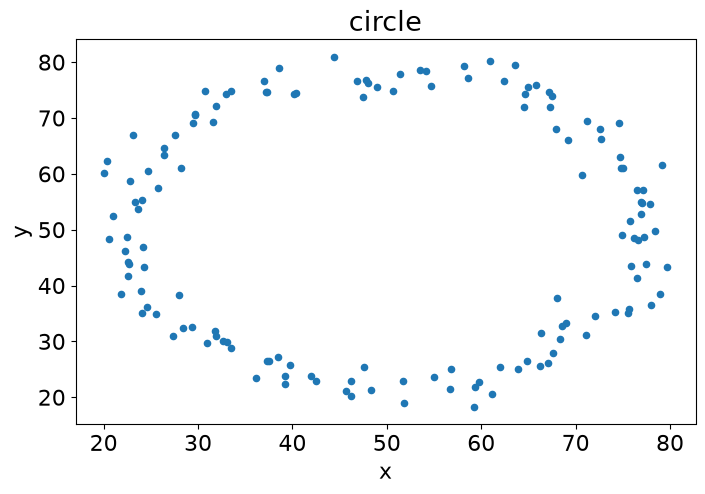

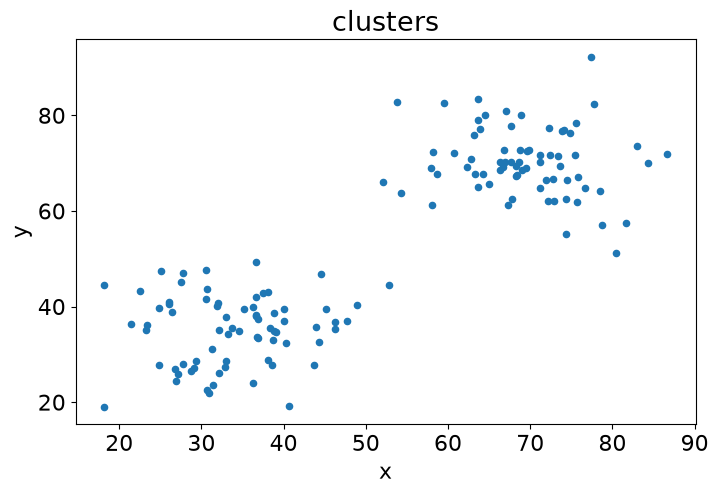

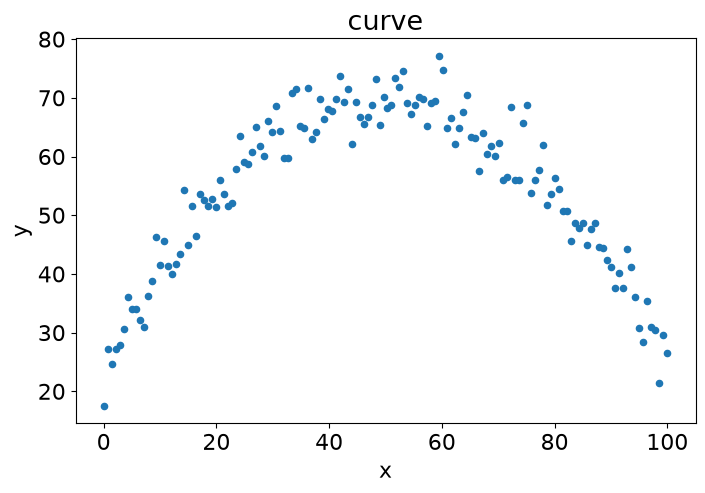

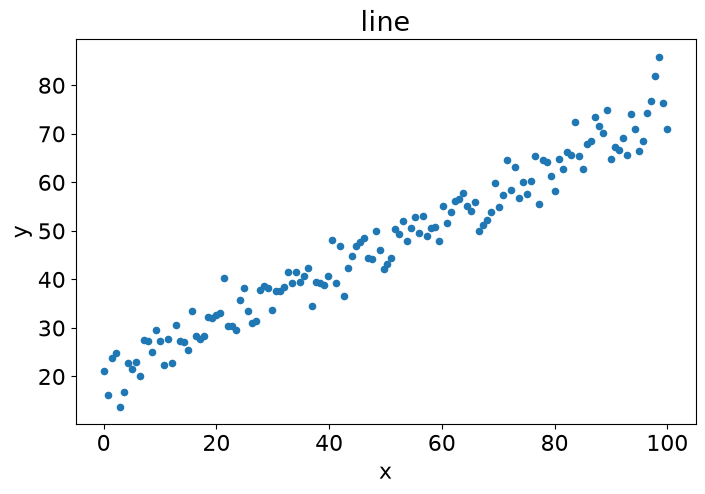

In [15]:
for name, part in df.groupby("dataset"):
    ax = part.plot(kind="scatter", x="x", y="y", title=name)
    plt.show()

<div style="font-size: 24px; line-height: 1.6;">

## Discussion

- What would a report of means and standard deviations hide here?
- Which dataset would you flag as suspicious if you only had the summary table?

</div>